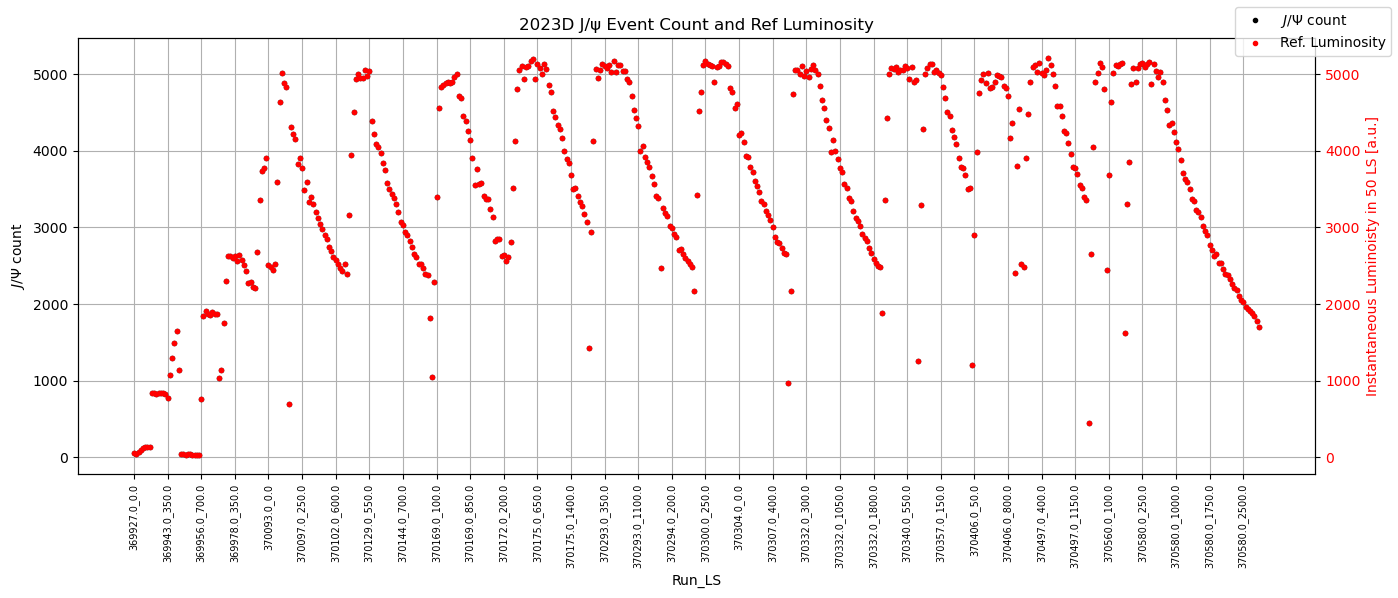

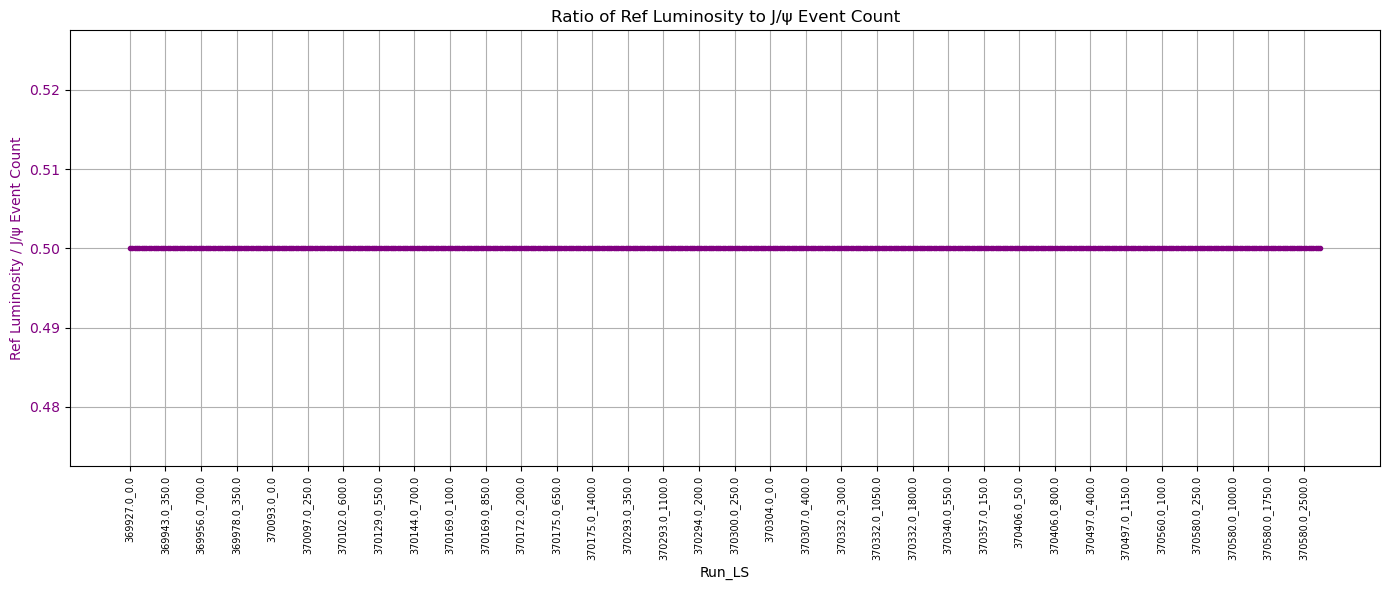

In [7]:
import ROOT
import uproot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Global observable
J_Mass = ROOT.RooRealVar("J_Mass", "J/#psi Mass", 2.9, 3.3, "GeV")

def read_root_file(file_path, cuts):
    """Read ROOT file and apply cuts."""
    tree = uproot.open(file_path)["ntuple"]
    branches_to_read = ["Run", "LumiBlock", "B_J1_mass", "B_Mu1_pt", "B_Mu2_pt"]
    arrays = tree.arrays(branches_to_read, library="np")

    # triggered_mask = arrays['TriggerFired'] == True
    triggered_mask = True

    # Apply cuts (e.g., for mass and other properties)
    mask = np.ones(len(arrays["Run"]), dtype=bool)
    for var, (low, high) in cuts.items():
        if low is not None:
            mask &= (arrays[var] > low)
        if high is not None:
            mask &= (arrays[var] < high)

    # Combine trigger and cuts
    final_mask = triggered_mask & mask

    # Apply the mask
    run = arrays["Run"][final_mask]
    lumiblock = arrays["LumiBlock"][final_mask]
    return run, lumiblock

def read_lumi_data(lumi_file):
    """Read luminosity data from brilcalc CSV."""
    df = pd.read_csv(lumi_file, skiprows=1, engine='python', skipfooter=5, parse_dates=['time'])
    df[['run', 'fill']] = df['#run:fill'].str.split(':', expand=True)
    df = df.drop(columns=['#run:fill'])
    df = df[['run', 'fill', 'time', 'ls', 'beamstatus', 'recorded(/ub)', 'delivered(/ub)', 'avgpu']]
    df['run'] = df['run'].astype(int)
    df['ls'] = df['ls'].apply(lambda x: x.split(':')[0]).astype(int)
    return df

def prepare_data(run, lumiblock, lumi_df, prescale_points=None, bin_width=50):
    prescale_points = prescale_points or []

    data = np.rec.fromarrays([run, lumiblock], names="run,lumiblock")
    data.sort(order=["run", "lumiblock"])

    event_counts = {}
    lumi_sums = {}
    lumi_counts = {}
    pileup_sums = {}

    # Fill event counts
    for r, l in zip(data.run, data.lumiblock):
        key = (r, l // bin_width)
        event_counts[key] = event_counts.get(key, 0) + 1

    # Fill luminosity and pileup sums
    for _, row in lumi_df.iterrows():
        r, l = row['run'], row['ls']
        recorded = row['recorded(/ub)']
        avgpu = row['avgpu']
        key = (r, l // bin_width)
        if key not in lumi_sums:
            lumi_sums[key] = 0
            pileup_sums[key] = 0
            lumi_counts[key] = 0
        lumi_sums[key] += recorded
        pileup_sums[key] += avgpu
        lumi_counts[key] += 1

    # Finalize bins
    all_keys = sorted(set(event_counts.keys()) | set(lumi_sums.keys()))
    event_y, lumi_y, pileup_y, x_labels = [], [], [], []
    bin_label_map = {}

    for key in all_keys:
        label = f"{key[0]}_{key[1]*bin_width}"
        x_labels.append(label)
        event_y.append(event_counts.get(key, 0))
        lumi_y.append(lumi_sums.get(key, 0) / lumi_counts.get(key, 1))
        pileup_y.append(pileup_sums.get(key, 0) / lumi_counts.get(key, 1))
        bin_label_map[key] = label

    prescale_lines = {
        bin_label_map.get((r, l // bin_width))
        for r, l in prescale_points
        if bin_label_map.get((r, l // bin_width))
    }

    return event_y, lumi_y, pileup_y, x_labels, sorted(prescale_lines)



def main():
    # Step 1: Read ROOT file and apply cuts
    cuts = {"B_J1_mass": (2.85, 3.35), "B_Mu1_pt": (7, None), "B_Mu2_pt": (7, None)}  # Apply J/ψ mass cut
    # root_file_path = "../preselection/parkingDoubleMuonLowMass/2023/PDMLM0_mm_2023D_v1_HLT_Dimuon0_Jpsi3p5_Muon2_v9.root"
    root_file_path = "../preselection/parkingDoubleMuonLowMass/2024/crab_TTree_136TeV_PDMLM0_mm_2023D_v2.root"
    run, lumiblock = read_root_file(root_file_path, cuts)

    prescale = [(385986, 1),
                (385986, 121),
                (385986, 283),
                (385986, 1434),
                (385986, 1543),
                (385986, 1641),
                (385986, 1922)]

    # Step 2: Read luminosity data
    lumi_file = '../preselection/parkingDoubleMuonLowMass/2024/lumi_normtagBRIL_PDMLM0_2023D.csv'
    lumi_df = read_lumi_data(lumi_file)
            
    # Step 3: Prepare data by combining ROOT and luminosity data
    event_y, lumi_y, pileup_y, x_labels, prescale_lines = prepare_data(run, lumiblock, lumi_df, prescale_points=prescale)

    # Scale lumi to match event counts
    lumi_max = max(lumi_y) if max(lumi_y) else 1
    event_max = max(event_y) if max(event_y) else 1
    scale_factor = lumi_max / event_max

    scaled_lumi_y = [y / scale_factor for y in lumi_y]
    
    # corrected_event_y = event_y
    corrected_event_y = []
    for i, lumi_y in enumerate(scaled_lumi_y):
        # corrected_event_y.append(lumi_y / (1.9 - lumi_y * 1.4e-5))
        corrected_event_y.append(lumi_y)

    fig, ax1 = plt.subplots(figsize=(14, 6))

    # Plot event counts
    ax1.plot(range(len(x_labels)), corrected_event_y, label="$J/ \Psi$ count", color="black", marker='.', linestyle='none')
    ax1.set_xlabel("Run_LS")
    ax1.set_ylabel("$J/ \Psi$ count", color="black")
    ax1.tick_params(axis='y', labelcolor="black")

    # Secondary axis for lumi and pileup
    ax2 = ax1.twinx()
    ax2.plot(range(len(x_labels)), scaled_lumi_y, label="Ref. Luminosity", color="red", marker='.', linestyle='none')

    # Axis label & legend
    ax2.set_ylabel("Instantaneous Luminoisty in 50 LS [a.u.]", color="red")
    ax2.tick_params(axis='y', labelcolor="red")
    import matplotlib.ticker as ticker

    ax1.xaxis.set_major_locator(ticker.MaxNLocator(50))
    visible_ticks = [int(tick) for tick in ax1.get_xticks() if 0 <= tick < len(x_labels)]
    ax1.set_xticks(visible_ticks)
    ax1.set_xticklabels([x_labels[i] for i in visible_ticks], rotation=90, fontsize=7)

    ax1.grid(True)
    fig.legend(loc='upper right')
    plt.title("2023D J/ψ Event Count and Ref Luminosity")
    fig.tight_layout()
    plt.savefig("Jpsi.png", dpi=300)

    # Compute ratio safely (avoid division by zero)
    event_y_arr = np.array(corrected_event_y)
    lumi_y_arr = np.array(scaled_lumi_y)
    ratio = np.zeros_like(lumi_y_arr)
    nonzero_mask = event_y_arr != 0
    ratio[nonzero_mask] = lumi_y_arr[nonzero_mask] / event_y_arr[nonzero_mask] / 2

    # Plot the ratio
    fig2, ax3 = plt.subplots(figsize=(14, 6))
    ax3.plot(range(len(x_labels)), ratio, color="purple", marker='.', linestyle='none')
    ax3.set_xlabel("Run_LS")
    ax3.set_ylabel("Ref Luminosity / J/ψ Event Count", color="purple")
    ax3.tick_params(axis='y', labelcolor="purple")

    ax3.xaxis.set_major_locator(ticker.MaxNLocator(50))
    visible_ticks_ratio = [int(tick) for tick in ax3.get_xticks() if 0 <= tick < len(x_labels)]
    ax3.set_xticks(visible_ticks_ratio)
    ax3.set_xticklabels([x_labels[i] for i in visible_ticks_ratio], rotation=90, fontsize=7)

    ax3.grid(True)
    plt.title("Ratio of Ref Luminosity to J/ψ Event Count")
    # plt.ylim(0.0, 1.5)
    fig2.tight_layout()
    plt.savefig("Jpsi_ratio.png", dpi=300)  


if __name__ == "__main__":
    main()
